In [42]:
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
sys.path.append('..')
from src.data_loader import load_data

In [43]:
file_path = Path('../data/mental_health.csv').resolve()
df = load_data(file_path)
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   str    
 3   Occupation                2000 non-null   str    
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   str    
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol            

## Описание признаков

| Признак | Тип | Описание |
|---|---|---|
| `Person_ID` | int | Уникальный идентификатор записи |
| `Age` | int | Возраст респондента |
| `Gender` | категориальный | Пол (Male / Female) |
| `Occupation` | категориальный | Занятость (Student / Employed) |
| `Daily_Screen_Time` | float | Общее время за экраном в сутки (часы) |
| `Social_Media_Usage` | float | Время в социальных сетях в сутки (часы) |
| `Night_Usage` | бинарный | Использование соцсетей ночью (0 — нет, 1 — да) |
| `Sleep_Hours` | float | Часов сна в сутки |
| `Stress_Level` | int | Уровень стресса (1–10) |
| `Work_Study_Hours` | float | Часов работы или учёбы в сутки |
| `Physical_Activity` | категориальный | Уровень физической активности (Low / High) |
| `Social_Interaction_Score` | int | Оценка социального взаимодействия (1–10) |
| `Caffeine_Intake` | int | Потребление кофеина (порций в день) |
| `Smoking` | бинарный | Курение (0 — нет, 1 — да) |
| `Alcohol` | бинарный | Употребление алкоголя (0 — нет, 1 — да) |
| `Depression` | бинарный | **Целевая переменная:** депрессия (0 — нет, 1 — да) |
| `Anxiety` | бинарный | **Целевая переменная:** тревожность (0 — нет, 1 — да) |
| `Burnout` | бинарный | **Целевая переменная:** выгорание (0 — нет, 1 — да) |

В датасете **3 целевых переменных**, моим таргетом будет *Depression*


In [45]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Посмотрим на распределение классов

Text(0, 0.5, 'Количество')

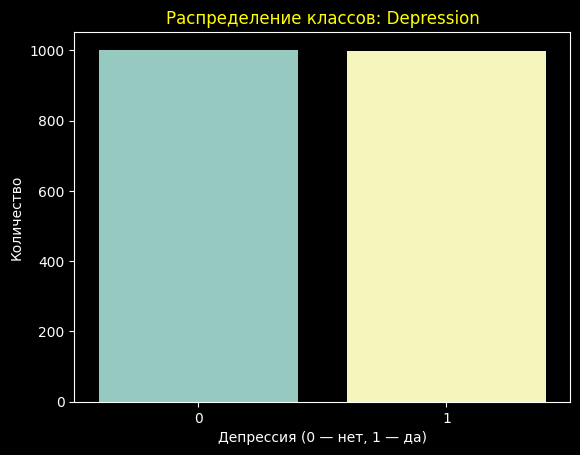

In [46]:
sns.countplot(data=df, x="Depression", hue="Depression", legend=False)
plt.title("Распределение классов: Depression", color="yellow")
plt.xlabel("Депрессия (0 — нет, 1 — да)")
plt.ylabel("Количество")

- Классы поровну распределены

### Посмотрим на распределения числовых признаков

array([[<Axes: title={'center': 'Person_ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Daily_Screen_Time'}>,
        <Axes: title={'center': 'Social_Media_Usage'}>],
       [<Axes: title={'center': 'Night_Usage'}>,
        <Axes: title={'center': 'Sleep_Hours'}>,
        <Axes: title={'center': 'Stress_Level'}>,
        <Axes: title={'center': 'Work_Study_Hours'}>],
       [<Axes: title={'center': 'Social_Interaction_Score'}>,
        <Axes: title={'center': 'Caffeine_Intake'}>,
        <Axes: title={'center': 'Smoking'}>,
        <Axes: title={'center': 'Alcohol'}>],
       [<Axes: title={'center': 'Depression'}>,
        <Axes: title={'center': 'Anxiety'}>,
        <Axes: title={'center': 'Burnout'}>, <Axes: >]], dtype=object)

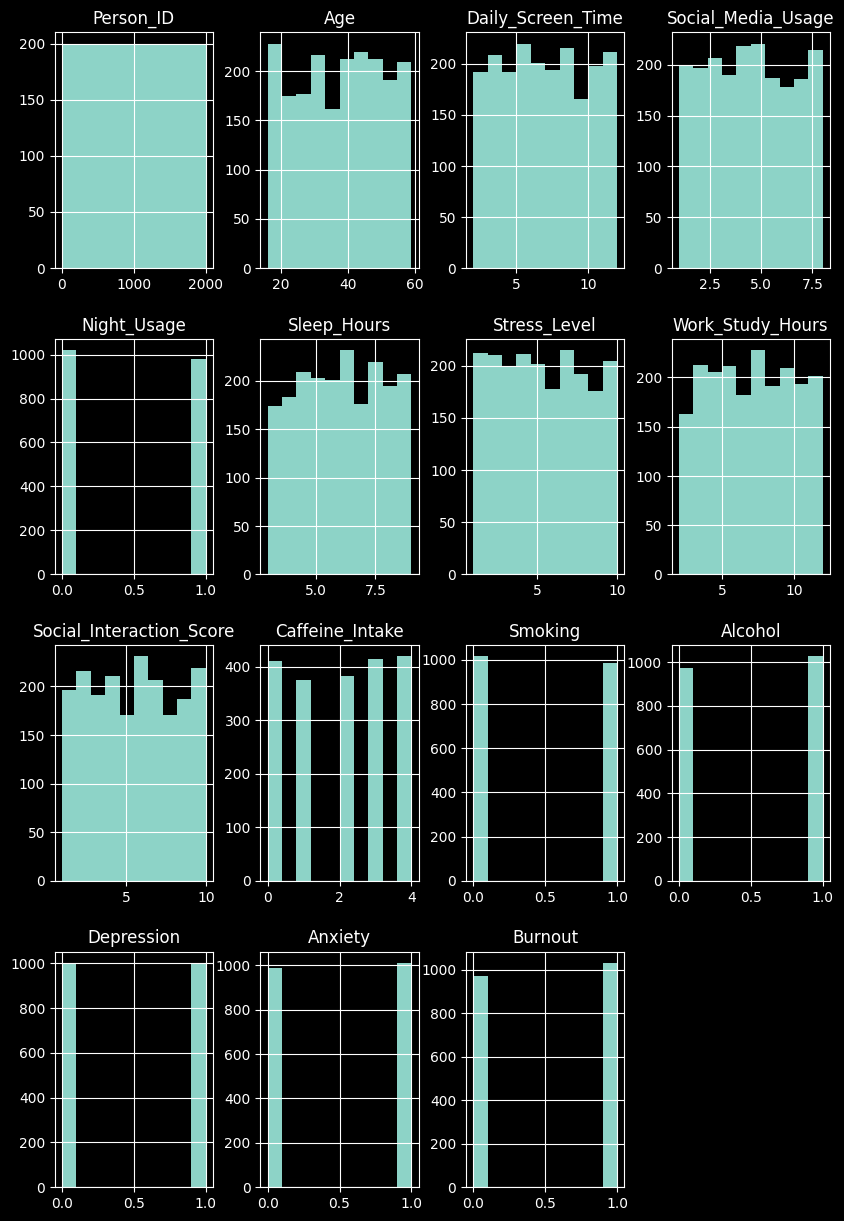

In [47]:
df.hist(figsize=(10,15))

### Распределение Категориальных признаков

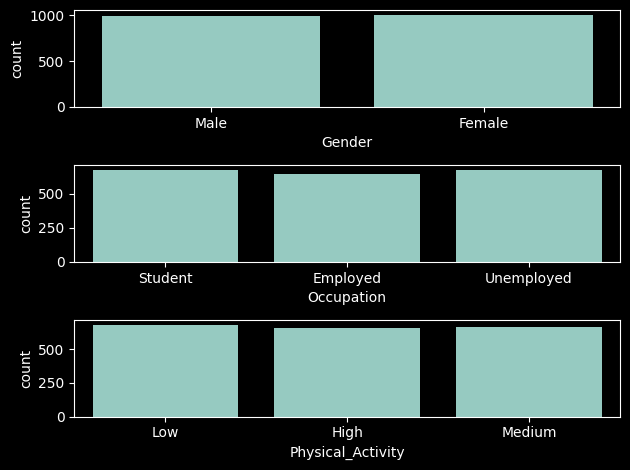

In [48]:
category_features = ["Gender", "Occupation", "Physical_Activity"]

fig, axes = plt.subplots(3, 1)

for i, col in enumerate(category_features):
    sns.countplot(data=df, x=col, ax=axes[i])
plt.tight_layout()

### За основной таргет возьму признак Depression, остальные не буду выводить для heatmap

In [49]:
df = df.drop(columns=["Person_ID"])

<Axes: >

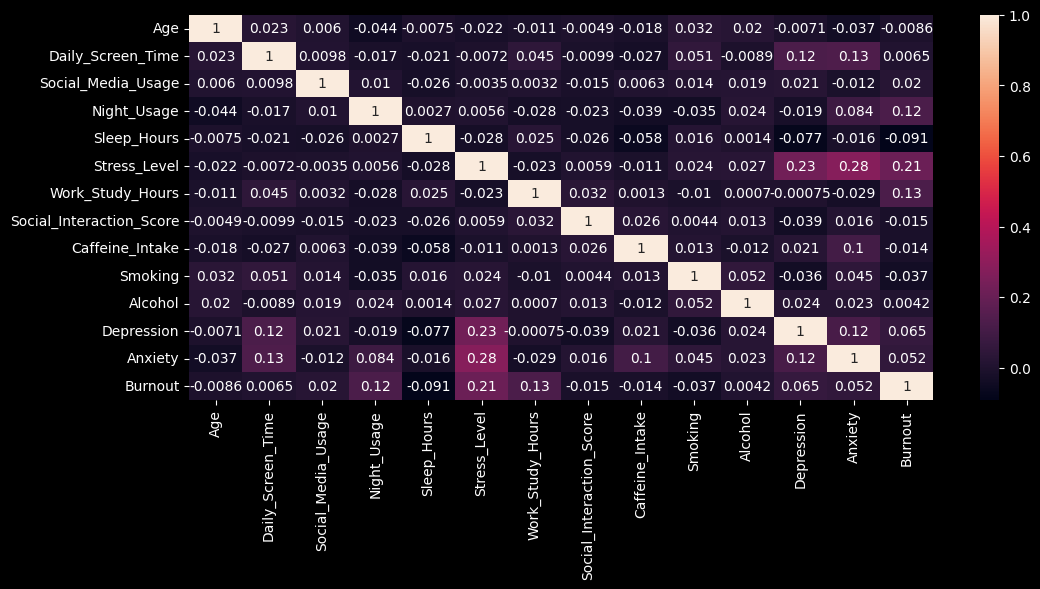

In [63]:
plt.figure(figsize=(12,5))
sns.heatmap(data=df.corr(numeric_only=True), annot=True, )


In [64]:
df.corr(numeric_only=True)["Depression"].sort_values(ascending=False)[1:]

Stress_Level                0.225461
Daily_Screen_Time           0.123482
Anxiety                     0.115029
Burnout                     0.065093
Alcohol                     0.024060
Social_Media_Usage          0.020670
Caffeine_Intake             0.020637
Work_Study_Hours           -0.000752
Age                        -0.007106
Night_Usage                -0.019046
Smoking                    -0.036037
Social_Interaction_Score   -0.038833
Sleep_Hours                -0.076989
Name: Depression, dtype: float64

In [71]:
result = df.groupby("Gender")["Depression"].mean().reset_index()
result.columns = ["Gender", "Depression_Rate"]
result

,Gender,Depression_Rate
0,Female,0.496032
1,Male,0.502016


In [72]:
df.groupby(["Night_Usage",
  "Depression"])["Social_Media_Usage"].mean()

Night_Usage  Depression
0            0             4.289641
             1             4.539306
1            0             4.500600
             1             4.411691
Name: Social_Media_Usage, dtype: float64

In [74]:
df.groupby("Gender")["Age"].mean()

,Gender,Age
0,Female,38.052579
1,Male,37.329637


In [84]:
df.groupby("Physical_Activity")["Depression"].mean().reset_index()


,Physical_Activity,Depression
0,High,0.489329
1,Low,0.520528
2,Medium,0.486405


In [87]:
df.groupby(["Gender", "Occupation"])["Stress_Level"].mean().reset_index()

,Gender,Occupation,Stress_Level
0,Female,Employed,5.623563
1,Female,Student,5.219880
2,Female,Unemployed,5.231707
3,Male,Employed,5.265101
4,Male,Student,5.443478
5,Male,Unemployed,5.633238


- Интересный паттерн: у женщин стресс выше когда работают, у мужчин когда не работают.

In [88]:
df.groupby(["Night_Usage", "Depression"])["Sleep_Hours"].mean()

Night_Usage  Depression
0            0             6.180876
             1             5.831214
1            0             6.096400
             1             5.924635
Name: Sleep_Hours, dtype: float64

- ночное использование само по себе почти не влияет на сон (6.18 vs 6.10 у недепрессивных)

In [92]:
table = df.pivot_table(index="Gender", columns="Depression", values="Daily_Screen_Time")
table["diff"] = table[1] - table[0]
table

Depression,0,1,diff
Gender,,,
Female,6.575197,7.420600,0.845403
Male,6.601215,7.178313,0.577099


- У людей с депрессией экранное время больше в обоих полах → подтверждает гипотезу проекта
- У женщин разница больше (0.85 ч vs 0.58 ч) депрессия у женщин сильнее связана со временем за экраном

In [96]:
df["screen_category"] = pd.cut(
    df["Daily_Screen_Time"],
    bins=[0,4,8,24],
    labels=["low", "medium", "high"]
)

df.groupby("screen_category")["Depression"].mean().reset_index()

,screen_category,Depression
0,low,0.417062
1,medium,0.481028
2,high,0.563732


Чёткая монотонная связь — чем больше экранного времени, тем выше доля людей с депрессией. Разница между
крайними группами ~14 процентов